
═══════════════════════════════════════════════════════
══════════════════ 📊 TABEL FREKUENSI ══════════════════
═══════════════════════════════════════════════════════
╒═════════╤═══════════════╤═════════╤═════════════╤══════════════╕
│  Score  │  Batas Bawah  │  Grade  │  Frequency  │  Percentage  │
╞═════════╪═══════════════╪═════════╪═════════════╪══════════════╡
│ 81-100  │      81       │    A    │     13      │     42%      │
├─────────┼───────────────┼─────────┼─────────────┼──────────────┤
│  76-80  │      76       │   AB    │      7      │     23%      │
├─────────┼───────────────┼─────────┼─────────────┼──────────────┤
│  66-75  │      66       │    B    │      4      │     13%      │
├─────────┼───────────────┼─────────┼─────────────┼──────────────┤
│  61-65  │      61       │   BC    │      1      │      3%      │
├─────────┼───────────────┼─────────┼─────────────┼──────────────┤
│  51-60  │      51       │    C    │      5      │     16%      │
├─────────┼───────────────┼

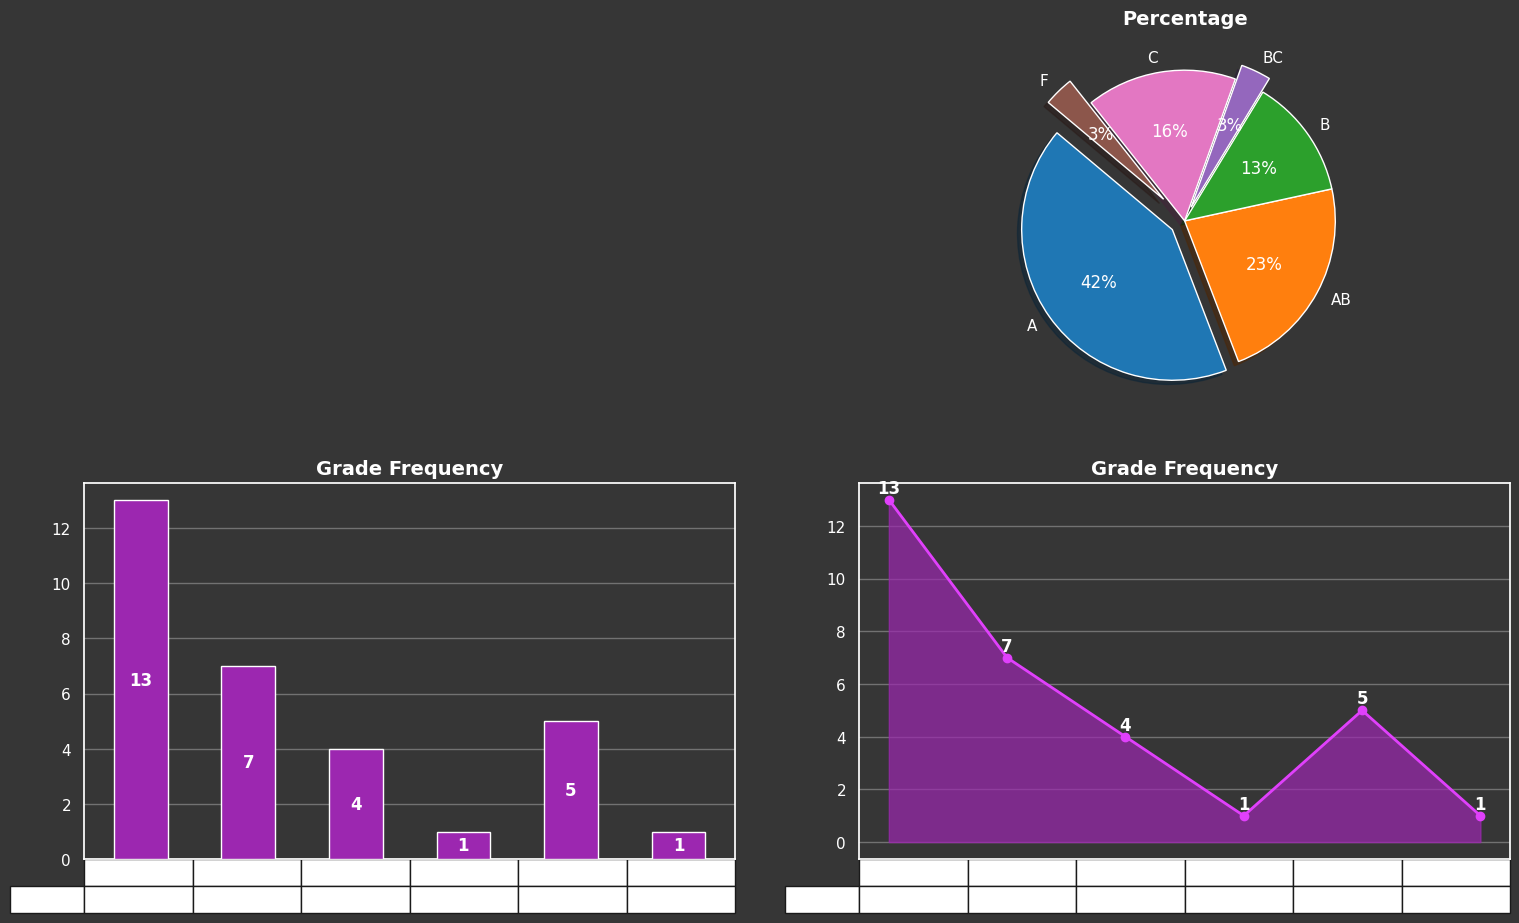

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

# ==========================================
# 1. IMPORT & PENGORGANISASIAN DATA
# ==========================================
file_path = 'LatihanPenyajianDataDanStatDesDenganExcel_ArkanFawwazSafii.xlsx'

dataraw = pd.read_excel(file_path, sheet_name=0, skiprows=6)
dataraw = dataraw.iloc[:, 1:8]
dataraw.columns = ["NIM", "Name", "KUIS", "UTS", "UAS", "Nilai", "Grade"]
dataraw = dataraw.dropna(subset=['NIM', 'Name'])
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors='coerce')

# ==========================================
# 2. PEMBUATAN TABEL FREKUENSI
# ==========================================
grade_order = ['A', 'AB', 'B', 'BC', 'C', 'F']
score_ranges = ['81-100', '76-80', '66-75', '61-65', '51-60', '0-50']
batas_bawah = [81, 76, 66, 61, 51, 0]

freq = dataraw['Grade'].value_counts().reindex(grade_order).fillna(0).astype(int)
total = freq.sum()
perc = (freq / total * 100).round().astype(int).astype(str) + '%'

freq_df = pd.DataFrame({
    'Score': score_ranges,
    'Batas Bawah': batas_bawah,
    'Grade': grade_order,
    'Frequency': freq.values,
    'Percentage': perc.values
})

print("\n" + "═"*55)
print(" 📊 TABEL FREKUENSI ".center(55, '═'))
print("═"*55)
print(tabulate(freq_df, headers='keys', tablefmt='fancy_grid', showindex=False,
               stralign='center', numalign='center'))
print("\n")

# ==========================================
# 3. STATISTIKA DESKRIPTIF
# ==========================================
dt = dataraw["Nilai"].dropna()

stats_data = [
    dt.mean(), dt.sem(), dt.median(),
    dt.mode().iloc[0] if not dt.mode().empty else np.nan,
    dt.std(), dt.var(), dt.kurtosis(), dt.skew(),
    dt.max() - dt.min(), dt.min(), dt.max(),
    dt.sum(), dt.count()
]

stats_index = [
    'Mean', 'Standard Error', 'Median', 'Mode',
    'Standard Deviation', 'Sample Variance', 'Kurtosis',
    'Skewness', 'Range', 'Minimum', 'Maximum', 'Sum', 'Count'
]

stats_df = pd.DataFrame({'Statistic': stats_index, 'Value': stats_data})

print("═"*55)
print(" 📈 DATA ANALYSIS ".center(55, '═'))
print("═"*55)
print(tabulate(stats_df.round(8), headers='keys', tablefmt='fancy_grid',
               showindex=False, stralign='left', numalign='right'))
print("\n")


# ==========================================
# 4. VISUALISASI DASHBOARD
# ==========================================
warna_bg = '#363636'
warna_bar = '#9C27B0'
warna_pie = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#e377c2', '#8c564b']

plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(warna_bg)

# ---- A. PIE CHART ----
ax1 = plt.subplot(2, 2, 2)
ax1.set_facecolor(warna_bg)
explode = (0.1, 0, 0, 0.1, 0, 0.2)
ax1.pie(freq.values, labels=grade_order, autopct='%1.0f%%', startangle=140,
        colors=warna_pie, explode=explode, shadow=True, textprops={'color': 'white'})
ax1.set_title('Percentage', color='white', fontweight='bold', fontsize=14)

# ---- B. BAR CHART DENGAN DATA TABLE ----
ax2 = plt.subplot(2, 2, 3)
ax2.set_facecolor(warna_bg)
bars = ax2.bar(grade_order, freq.values, color=warna_bar, width=0.5, zorder=3)
ax2.set_title('Grade Frequency', color='white', fontweight='bold', fontsize=14)
ax2.grid(axis='y', linestyle='-', alpha=0.3, zorder=0)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax2.annotate(f'{yval}', xy=(bar.get_x() + bar.get_width()/2, yval/2),
                     ha='center', va='center', color='white', fontweight='bold')

ax2.set_xticks([])
tabel_bar = ax2.table(cellText=[freq.values], rowLabels=['Series 1'],
                      colLabels=grade_order, loc='bottom', cellLoc='center')
tabel_bar.set_fontsize(11)
tabel_bar.scale(1, 1.5)

# ---- C. AREA CHART DENGAN DATA TABLE ----
ax3 = plt.subplot(2, 2, 4)
ax3.set_facecolor(warna_bg)
ax3.plot(grade_order, freq.values, color='#E040FB', marker='o', linewidth=2)
ax3.fill_between(grade_order, freq.values, color=warna_bar, alpha=0.7)
ax3.set_title('Grade Frequency', color='white', fontweight='bold', fontsize=14)
ax3.grid(axis='y', linestyle='-', alpha=0.3)

for i, v in enumerate(freq.values):
    ax3.annotate(str(v), xy=(i, v), xytext=(0, 5), textcoords='offset points',
                 ha='center', color='white', fontweight='bold')

ax3.set_xticks([])
tabel_area = ax3.table(cellText=[freq.values], rowLabels=['Series 1'],
                       colLabels=grade_order, loc='bottom', cellLoc='center')
tabel_area.set_fontsize(11)
tabel_area.scale(1, 1.5)

plt.tight_layout(pad=3.0)
plt.show()